### SVM Linéaire sur MNIST

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_openml
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef
)
from sklearn.preprocessing import StandardScaler
import time

In [4]:
# CHARGEMENT & PREPROCESSING

print("Chargement de MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X, y = mnist.data, mnist.target.astype(int)

# Sous-échantillonnage équilibré : 1 000 exemples par classe = 10 000 points
np.random.seed(42)
idx = np.concatenate([
    np.random.choice(np.where(y == c)[0], 1000, replace=False)
    for c in range(10)
])
X, y = X[idx], y[idx]
print(f"    Shape X : {X.shape}  |  Classes : {np.unique(y)}")

# Normalisation [0, 1] + StandardScaler
X_norm   = X / 255.0
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"    Normalisation [0,1] + StandardScaler appliqués | Shape : {X_scaled.shape}")

# Split 80/20 stratifié
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"    Train : {X_tr.shape[0]} | Test : {X_te.shape[0]}")

Chargement de MNIST...
    Shape X : (10000, 784)  |  Classes : [0 1 2 3 4 5 6 7 8 9]
    Normalisation [0,1] + StandardScaler appliqués | Shape : (10000, 784)
    Train : 8000 | Test : 2000


In [5]:
# ENTRAÎNEMENT SVM LINÉAIRE — C fixe

C_FIXED = 0.01
t0 = time.time()
svm = LinearSVC(C=C_FIXED, max_iter=2000, random_state=42)
svm.fit(X_tr, y_tr)
t_fit = time.time() - t0

y_pred_cfg = svm.predict(X_te)
acc = accuracy_score(y_te, y_pred_cfg)
bal_acc = balanced_accuracy_score(y_te, y_pred_cfg)
f1_macro = f1_score(y_te, y_pred_cfg, average="macro")

results = [{
    "svm": svm,
    "C": C_FIXED,
    "label": f"C={C_FIXED}",
    "acc": acc,
    "bal_acc": bal_acc,
    "f1_macro": f1_macro,
    "time": t_fit,
}]
best = results[0]

print(
    f"    C={C_FIXED:<6} → Acc : {acc:.4f} ({acc*100:.1f}%) | "
    f"BalAcc : {bal_acc:.4f} | F1-macro : {f1_macro:.4f}  [{t_fit:.1f}s]"
 )
print(f"\n    Modèle retenu : C={best['C']} → {best['acc']*100:.1f}%")

    C=0.01   → Acc : 0.8860 (88.6%) | BalAcc : 0.8860 | F1-macro : 0.8856  [93.9s]

    Modèle retenu : C=0.01 → 88.6%


In [6]:
# ÉVALUATION

svm_best = best["svm"]
y_pred   = svm_best.predict(X_te)
acc      = accuracy_score(y_te, y_pred)
bal_acc  = balanced_accuracy_score(y_te, y_pred)
mcc      = matthews_corrcoef(y_te, y_pred)

precision_macro = precision_score(y_te, y_pred, average="macro")
recall_macro    = recall_score(y_te, y_pred, average="macro")
f1_macro        = f1_score(y_te, y_pred, average="macro")

precision_weighted = precision_score(y_te, y_pred, average="weighted")
recall_weighted    = recall_score(y_te, y_pred, average="weighted")
f1_weighted        = f1_score(y_te, y_pred, average="weighted")

error_rate = 1 - acc

print(f"    Accuracy finale        : {acc:.4f} ({acc*100:.1f}%)")
print(f"    Balanced Accuracy      : {bal_acc:.4f}")
print(f"    MCC                    : {mcc:.4f}")
print(f"    Taux d'erreur          : {error_rate:.4f} ({error_rate*100:.1f}%)")

print("\n    Macro averages:")
print(f"      Precision macro      : {precision_macro:.4f}")
print(f"      Recall macro         : {recall_macro:.4f}")
print(f"      F1 macro             : {f1_macro:.4f}")

print("\n    Weighted averages:")
print(f"      Precision weighted   : {precision_weighted:.4f}")
print(f"      Recall weighted      : {recall_weighted:.4f}")
print(f"      F1 weighted          : {f1_weighted:.4f}")

report = classification_report(y_te, y_pred, output_dict=True)
print(f"\n    F1-score par classe :")
for digit in range(10):
    f1  = report[str(digit)]["f1-score"]
    bar = "█" * int(f1 * 20)
    print(f"      Chiffre {digit} : {bar:<20} {f1:.3f}")

# Points proches de la frontière de décision
margins          = np.min(np.abs(svm_best.decision_function(X_te)), axis=1)
n_near_boundary  = np.sum(margins < 0.5)
print(f"\n    Points proches de la frontière (marge < 0.5) : {n_near_boundary}/{len(X_te)}")

    Accuracy finale        : 0.8860 (88.6%)
    Balanced Accuracy      : 0.8860
    MCC                    : 0.8734
    Taux d'erreur          : 0.1140 (11.4%)

    Macro averages:
      Precision macro      : 0.8862
      Recall macro         : 0.8860
      F1 macro             : 0.8856

    Weighted averages:
      Precision weighted   : 0.8862
      Recall weighted      : 0.8860
      F1 weighted          : 0.8856

    F1-score par classe :
      Chiffre 0 : ██████████████████   0.924
      Chiffre 1 : ██████████████████   0.926
      Chiffre 2 : █████████████████    0.872
      Chiffre 3 : █████████████████    0.860
      Chiffre 4 : █████████████████    0.882
      Chiffre 5 : █████████████████    0.858
      Chiffre 6 : ██████████████████   0.930
      Chiffre 7 : ██████████████████   0.918
      Chiffre 8 : ████████████████     0.849
      Chiffre 9 : ████████████████     0.837

    Points proches de la frontière (marge < 0.5) : 944/2000


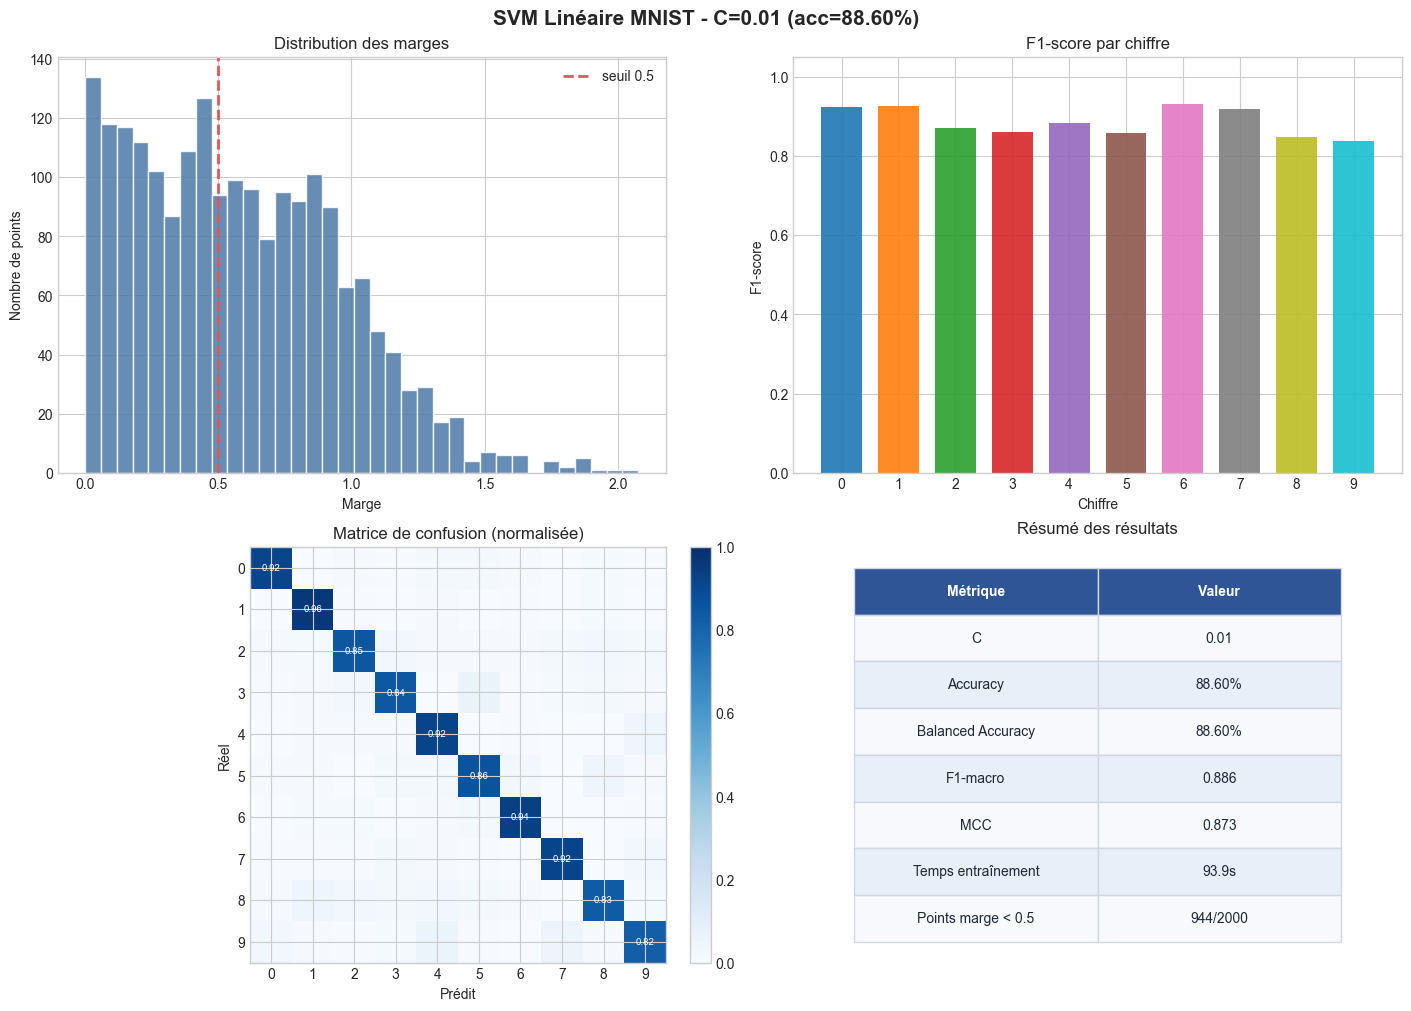

Pipeline terminé ✓


In [7]:
# VISUALISATION (compacte et utile)

COLORS = plt.cm.tab10(np.linspace(0, 1, 10))
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle(f"SVM Linéaire MNIST - C={best['C']} (acc={acc:.2%})", fontsize=15, fontweight="bold")

# Panel 1: Distribution des marges
ax1 = axes[0, 0]
ax1.hist(margins, bins=35, color="#4E79A7", alpha=0.85, edgecolor="white")
ax1.axvline(0.5, color="#E15759", linestyle="--", linewidth=2, label="seuil 0.5")
ax1.set_title("Distribution des marges")
ax1.set_xlabel("Marge")
ax1.set_ylabel("Nombre de points")
ax1.legend()

# Panel 2: F1-score par chiffre
ax2 = axes[0, 1]
rep_fixed = classification_report(y_te, y_pred, output_dict=True)
f1s = [rep_fixed[str(d)]["f1-score"] for d in range(10)]
ax2.bar(range(10), f1s, color=COLORS, alpha=0.9, width=0.72)
ax2.set_ylim(0, 1.05)
ax2.set_title("F1-score par chiffre")
ax2.set_xlabel("Chiffre")
ax2.set_ylabel("F1-score")
ax2.set_xticks(range(10))

# Panel 3: Matrice de confusion normalisée
ax3 = axes[1, 0]
cm = confusion_matrix(y_te, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax3.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax3.set_title("Matrice de confusion (normalisée)")
ax3.set_xlabel("Prédit")
ax3.set_ylabel("Réel")
ax3.set_xticks(range(10))
ax3.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        val = cm_norm[i, j]
        if val > 0.10:
            ax3.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=7,
                color="white" if val > 0.5 else "#1f3b73"
            )
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

# Panel 4: Résumé des métriques
ax4 = axes[1, 1]
ax4.axis("off")
summary = [
    ["Métrique", "Valeur"],
    ["C", f"{best['C']}"],
    ["Accuracy", f"{acc:.2%}"],
    ["Balanced Accuracy", f"{bal_acc:.2%}"],
    ["F1-macro", f"{f1_macro:.3f}"],
    ["MCC", f"{mcc:.3f}"],
    ["Temps entraînement", f"{best['time']:.1f}s"],
    ["Points marge < 0.5", f"{n_near_boundary}/{len(X_te)}"],
]
table = ax4.table(
    cellText=summary[1:],
    colLabels=summary[0],
    cellLoc="center",
    loc="center",
    bbox=[0.1, 0.05, 0.8, 0.9]
 )
table.auto_set_font_size(False)
table.set_fontsize(10)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2F5597")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#E9EFF8" if r % 2 == 0 else "#F7F9FC")
        cell.set_text_props(color="#1F2937")
    cell.set_edgecolor("#D0D7E2")
ax4.set_title("Résumé des résultats", pad=10)

plt.savefig("svm_lineaire_mnist.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Pipeline terminé ✓")